# Lab 9 Report: 
## Final Project Codebase

## Project Title: Galaxy Classifier: CNN & CvT

### Group Members: Simon Harty 

### Dataset for your project: Galaxy Zoo

---

## Understanding the Data

a. Data size and structure: How big is the data? How is it structured? Are there any
obvious patterns? If so, are they expected? Any unused features? Etc
- There are 61578 training galaxies, and 79975 test galaxies. Images are 424 * 424 pixels. There are provided probability distributions for the training set, but not the testing set. The later classes have smaller probabilities. This makes sense as not every decision tree will lead to them, unlike the early questions. Class 1.1-1.3 always sum to one, as well as class 6.1 and 6.2.

b. Data cleanness Is some of the data corrupted? Is some data mislabeled? If it's
simulated, does the simulator have any limitations
- Some of the images are strangely color shifted / have some artifacting. Some of the probability entries are filled with hastags rather than a number.

c. Diversity of features: How many features (e.g., # of pixels, # of columns) are
there per data sample? Does your dataset have approximately equal number of
datapoints per label?
- The images are 424 * 424 (so 179776) pixels. Since we are generating probability distributions, each galaxy has a value (even if it is zero) for each class.

## Understanding the Task

a. What problem are you trying to solve with your neural network model? (e.g.,
classification or regression?)
- While this is a galaxy classifier, the problem is actually a regression problem. We are predicting probabilities for each calss, rather than predicting a 'true'  class.

b. What is the significance of solving the problem?
- Due to the large amount of glaxies that need classification, it is impossible to calssify them by hand. Understanding the environments and ages of different galactic types will help us understand galaxy evolution.

c. What will be the evaluation metric for your neural network model?
- Root mean squared error, as is used in the original kaggle challenge.

d. What would constitute a good performance?
- Distinguishing smooth galaxies from feature/disks with ~ 90% accuracy like Benjeri et al. (2010). The winner of the competition got a score (on Kaggle) of 0.07491. Anything close to this would be fantastic.

e. Is there a baseline method to compare against after meeting the performance?
(e.g., classical machine learning method, other neural network models)
- There are other neural nets to compare against. Many submissions in the kaggle challenge, and some papers about this dataset.

## Developing an initial plan for your project

a. What will be the inputs and outputs (including their dimensions) of your neural
network model? What data preparation methods do you plan to use?
- Inputs will be 64 * 64 * 3 color images. If these are too large, I will downsize to 32 * 32. The outputs will be vectors corresponding to probabilites, that each have 37 values. I plan to randomly rotate, crop, and downsample each image.

b. What neural network model do you plan to use? (FCN, CNN, RNN, etc)
- I plan to use a CNN, EvT, FCN hybrid network.

c. What loss function do you plan to use?
- Mean squared error.

d. How do you plan to evaluate your model?
- I will make a validation set from the training set and sum the RMSE from the expected probabilities. The lower the number, the better. I also plan to upload my solution file to kaggle, and see where my model ranks there.


In [ ]:
from torchvision import transforms
from torchvision.models.vision_transformer import EncoderBlock
from torch.utils.data import DataLoader, Dataset
import torch

import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import pandas as pd
import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CROP_SIZE = 207
INPUT_SIZE = 64
N_WORKERS = 0 # tried multiprocessing, but code hangs if not set to zero
RUN = False # Determines if notebook trains model
MAKE_TEST = False # determines if notebook makes a testing csv for kaggle submission

DEVICE # check device

'cpu'

## Prepare Data

In [ ]:
#make a class to transform, store, and organize data
class GalaxyDataset(Dataset):
    """Dataset of preprocessed galaxy images"""
    def __init__(self, image_paths, labels_csv, transform=None, cache_path=None):
        self.transform = transform

        if cache_path and Path(cache_path).exists():
            # caching logic to avoid preprocessing on consecutive runs
            cache = torch.load(cache_path, weights_only=False)
            self.images = cache['images']
            self.galaxy_ids = cache['galaxy_ids']
            self.labels_df = cache['labels_df']
            
        
        else:
            # preproccessing transforms
            pre = transforms.Compose([
                transforms.CenterCrop(CROP_SIZE), # crop
                transforms.Resize(INPUT_SIZE), # resize / downsample
                transforms.ToTensor()]) # transform to tensors
            
            # store ids, images, and class probabilities
            self.galaxy_ids = [int(p.stem) for p in image_paths]
            self.images = torch.stack([pre(Image.open(p).convert("RGB")) for p in tqdm.tqdm(image_paths)]).half()
            self.labels_df = pd.read_csv(labels_csv, index_col="GalaxyID")

            # caching logic - saves the transformed data
            if cache_path:
                torch.save({'images': self.images,
                            'galaxy_ids': self.galaxy_ids,
                            'labels_df': self.labels_df},
                            cache_path)

    # function to return the image and class probabilities for a galaxy
    # index based, not based on galaxy id
    # the passed transform method is applied here to allow testing different transforms
    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform:
            img = self.transform(img)
        label_values = self.labels_df.loc[self.galaxy_ids[idx]].values
        label = torch.tensor(label_values, dtype=torch.float32, device=img.device)

        return img, label
    
    # returns to number of stored galaxies
    def __len__(self):
        return len(self.images)
    
class GalaxyTestDataset(Dataset):
        """Dataset of preprocessed test galaxy images, handled differently for testing purposes"""

        # note the lack of labels
        def __init__(self, base_dataset):
            self.images = base_dataset.images
            self.galaxy_ids = base_dataset.galaxy_ids
            self.transform = base_dataset.transform

        # with a normal dataset, this method would crash without access to
        # galaxy class probabilities (labels)
        def __getitem__(self, idx):
            img = self.images[idx]
            if self.transform:
                img = self.transform(img)
                
            # must return a dummy label array of zeros so the DataLoader structure matches
            dummy_label = torch.zeros(37, dtype=torch.float32, device=img.device)
            return img, dummy_label

        def __len__(self):
            return len(self.images)

In [3]:
# get paths to all the image data
data_dir   = Path(r"C:\Users\harty\Code\Galaxy-Classifier\Data\images_training_rev1")
test_dir = Path(r"C:\Users\harty\Code\Galaxy-Classifier\Data\images_test_rev1")
labels_csv = r"C:\Users\harty\Code\Galaxy-Classifier\Data\training_solutions_rev1.csv"
data_paths  = sorted(data_dir.glob("*.jpg"))
test_paths = sorted(test_dir.glob("*.jpg"))

# get random indices to create validation set (10% of training data)
indices = torch.randperm(len(data_paths), generator=torch.Generator().manual_seed(42))
n_val   = int(len(data_paths) * 0.1)

# paths for training and validation sets
train_paths = [data_paths[i] for i in indices[n_val:]]
val_paths   = [data_paths[i] for i in indices[:n_val]]

In [ ]:
# load training data without normalization to compute average and stdev
train_set = GalaxyDataset(train_paths, labels_csv,
                          transform=None, cache_path='train_set.pth')

# get averages and stdevs for each color in the image
train_mean = train_set.images.mean(dim=[0, 2, 3]).tolist()
train_std = train_set.images.std(dim=[0, 2, 3]).tolist()

# presprocessing transforms to apply to inputs
train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=(0, 360)), # random rotation
    transforms.Normalize(mean=train_mean, std=train_std)]) # normalize with training means and stds

# use training means and stds in normalization to treat validation data as 'unseen'
# do not randomly rotate the validation data for the same reason
val_transform = transforms.Compose([
    transforms.Normalize(mean=train_mean, std=train_std)])

# load in training and testing data with above transforms
train_set = GalaxyDataset(train_paths, labels_csv,
                          transform=train_transform,
                          cache_path='train_set.pth')
val_set = GalaxyDataset(val_paths, labels_csv,
                        transform=val_transform,
                        cache_path='val_set.pth')

# push all images to device for faster training
# I honestly cannot tell if this helped or not
train_set.images = train_set.images.to(DEVICE)
val_set.images = val_set.images.to(DEVICE)

In [ ]:
# check sizes
print(train_set.__len__(), val_set.__len__())

[0.10345458984375, 0.08953857421875, 0.0703125] [0.1444091796875, 0.1209716796875, 0.10443115234375]
55421 6157


## Define Model

In [ ]:
import torch
import torch.nn as nn

# CNN block
class ConvBlock(nn.Module):
    """Two CNN layers with batch normalization and ReLU activation. Followed by one MaxPooling layer."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2))

    def forward(self, x):
        return self.block(x)


class ConvTokenizer(nn.Module):
    """Projects feature map into a sequence of tokens for the transformer."""
    def __init__(self, in_channels, embed_dim):
        super().__init__()
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=1)

    def forward(self, x):
        x = self.proj(x) # project features into patches
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2) # reshape to be able to pass into CvT
        return x


class CvTBlock(nn.Module):
    """Uses PyTorch's EncoderBlock for the convolutional vision transformer."""
    def __init__(self, embed_dim, num_heads, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        
        # calculates the multilayer perceptron dimension using mlp_dim
        mlp_dim = int(embed_dim * mlp_ratio)
        
        # combines LayerNorm, MultiheadAttention, and the MLP
        self.transformer_layer = EncoderBlock(
            num_heads=num_heads,
            hidden_dim=embed_dim,
            mlp_dim=mlp_dim,
            dropout=dropout,
            attention_dropout=dropout,
            norm_layer=nn.LayerNorm)

    def forward(self, x):
        return self.transformer_layer(x)


class GalaxyClassifier(nn.Module):
    "Full Galaxy Classifier network. Combines the CNNBlcok, Tokenizer, and CvTBlock."
    "Adds a FC Block to the network, using dropout and ReLU activation."
    def __init__(
        self,
        in_channels: int = 3,
        num_outputs: int = 37,
        conv_channels: int = 16,
        embed_dim: int = 16,
        num_heads: int = 2,
        num_cvt_layers: int = 1,
        fc_dim: int = 64,
        dropout: float = 0.4):

        super().__init__()

        # CNN block
        self.conv_block = ConvBlock(in_channels, conv_channels)

        # CvT block
        self.tokenizer = ConvTokenizer(conv_channels, embed_dim)
        self.cvt = nn.Sequential(*[CvTBlock(embed_dim, num_heads, dropout=dropout)
                                   for _ in range(num_cvt_layers)])

        # FC layers
        self.fc = nn.Sequential(
            nn.Linear(embed_dim, fc_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(fc_dim, fc_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(fc_dim // 2, num_outputs),
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = self.tokenizer(x)
        x = self.cvt(x)
        x = x.mean(dim=1) # average pooling to reshape and pass into the FC layers
        raw_outputs = self.fc(x)

        # apply softmax to classes 1 and 6, as each of these classes have probabilties
        # that sum to one
        x[:, 0:3] = torch.softmax(raw_outputs[:, 0:3], dim=-1)
        x[:, 13:15] = torch.softmax(raw_outputs[:, 13:15], dim=-1)

        # clamp outputs between 0 and 1 as they are probabilities.
        x = torch.clamp(raw_outputs, 0.0, 1.0) 
        return x

# initialize model and push to device
model = GalaxyClassifier().to(DEVICE)

# 4 'dummy' images to test if model takes and gives inputs / outputs
# of correct shape without crashing
dummy = torch.randn(4, 3, 64, 64).to(DEVICE)
out = model(dummy)
print(f"Output shape: {out.shape}") # expect [4, 37]
# calculate number of model parameters
print(f"Params: {sum(p.numel() for p in model.parameters()):,}") 

Output shape: torch.Size([4, 37])
Params: 112,805


## Define Hyperparameters

In [ ]:
BATCH_SIZE = 64
EPOCHS = 24
LR = 1e-3
WD = 1e-2

optimizer = torch.optim.AdamW(model.parameters(), lr = LR, weight_decay=WD)
# RMSE was used in original challenge, so I use MSE and take the
# square root of it during training
loss_func = torch.nn.MSELoss()

## Identify Tracked Values

In [ ]:
train_losses = []
val_losses = []

## Train Model

In [ ]:
from torch.utils.data import Subset
# control the number of batches to limit number of
# galaxies used in training efficiently
num_batches = 160

if RUN == True:
    # get subsets of training and validation data based on num batches and batchsize
    train_subset = Subset(train_set, range(BATCH_SIZE*num_batches))
    val_subset = Subset(val_set, range(BATCH_SIZE*(num_batches // 2)))
    # set up minibatches
    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE,
                              shuffle=True,  num_workers=N_WORKERS)
    val_loader   = DataLoader(val_subset,   batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=N_WORKERS)
    # data is saved as float16 to conserve RAM, this scales it back to float32
    scaler = torch.amp.GradScaler(device=DEVICE.type)

    # Training Loop ---------------------------------------------------------------------------------------
    for epoch in tqdm.trange(EPOCHS):
        model.train()
        running_loss = 0

        for imgs, labels in train_loader:
            optimizer.zero_grad()
            with torch.amp.autocast(device_type=DEVICE.type): # more float16 -> 32 casting
                outputs = model(imgs)
                loss = loss_func(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * imgs.size(0)

        train_losses.append((running_loss / len(train_subset)) ** 0.5) # track loss only per epoch

        # Compute Validation Accuracy ----------------------------------------------------------------------
        model.eval()
        running_loss = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                with torch.amp.autocast(device_type='cuda'):
                    outputs = model(imgs)
                    loss = loss_func(outputs, labels)
                running_loss += loss.item() * imgs.size(0)
                
            val_losses.append((running_loss / len(val_subset)) ** 0.5) # track once per epoch


In [ ]:
if RUN == True:
    # save the model along with loss curve data so I can test different parameters and keep the best one
    # format: model_{RMSE}.pth
    torch.save({'model_state_dict': model.state_dict(),
                'train_losses': train_losses,
                'val_losses': val_losses},
                f"model_{val_losses[-1]:.3f}.pth")

## Visualize & Evaluate Models

I trained multiple models for this project. I will visualize the model used in my poster, as well as my best performing model.

In [ ]:
# helper function to plot a model
def plot_loss(path, model):
    # load saved model
    checkpoint = torch.load(path, map_location=DEVICE, weights_only=False)

    # get losses and model from file
    model.load_state_dict(checkpoint['model_state_dict'])
    train_losses = checkpoint['train_losses']
    val_losses = checkpoint['val_losses']

    model.eval()

    # plot training and validation loss
    plt.figure(figsize=(12, 8))
    plt.plot(train_losses, label="Train Loss", marker='o')
    plt.plot(val_losses, label="Val Loss", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("RMSE Loss")
    plt.title("Galaxy Classifier Training History")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()


In [ ]:
model_path = "model_0.115.pth" # model path 
model = GalaxyClassifier().to(DEVICE) # untrained model with same dimensions as the one in model_path
plot_loss(model_path, model)

NameError: name 'GalaxyClassifier' is not defined

In [ ]:

# this block will generate a file of galaxy predicitons for the testing dataset.
# the only way to get your loss for these galaxies is to submit it to the kaggle page
# as testing labels were not provided

if MAKE_TEST == True:        
    # create standard test set object
    raw_test_set = GalaxyDataset(test_paths, labels_csv, transform=val_transform,
                                 cache_path='test_set.pth')
    # wrap it in GalaxyTestDataset to block getitem crashes
    test_set = GalaxyTestDataset(raw_test_set)
    test_set.images = test_set.images.to(DEVICE) # push to device
    # set up batches
    test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=N_WORKERS)
    model.eval()
    all_predictions = []

    with torch.no_grad():
        # loop through all images in testing set and track label predictions
        for imgs, _ in tqdm.tqdm(test_loader, smoothing=0):
            with torch.amp.autocast(DEVICE.type):
                outputs = model(imgs)
            all_predictions.extend(outputs.cpu().float().numpy().tolist())

    # gets the column names from my labels csv file
    # drops the GalaxyID column to match model output shape
    column_names = pd.read_csv(labels_csv, nrows=1).columns.tolist()
    if 'GalaxyID' in column_names:
        column_names.remove('GalaxyID')

    # turn prediction list into a dataframe
    # adds the test dataset galaxy id's as the GalaxyID column
    submission_df = pd.DataFrame(all_predictions, columns=column_names)
    submission_df.insert(0, 'GalaxyID', test_set.galaxy_ids)

    # saves the predictions as a csv
    output_path = r"C:\Users\harty\Code\Galaxy-Classifier\test_predictions.csv"
    submission_df.to_csv(output_path, index=False)

    # check shape
    print(f"Prediction file shape: {submission_df.shape}")


Generating Predictions: 100%|██████████| 1250/1250 [03:32<00:00,  5.87it/s]


Prediction file generated with shape (79975, 38) at:
C:\Users\harty\Code\Galaxy-Classifier\test_predictions.csv


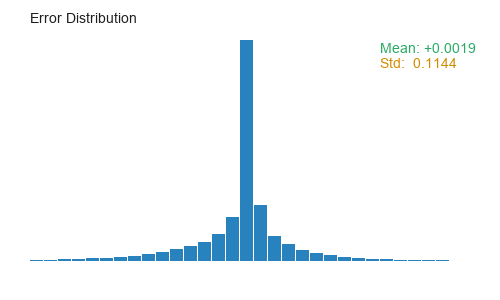

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader

model.eval()
all_preds = [] # model outputs
all_trues = [] # ground truths

# set up batches for entire validation set
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=N_WORKERS)

# predictions for entire validation set
with torch.no_grad():
    for imgs, labels in val_loader:
        with torch.amp.autocast(DEVICE.type):
            outputs = model(imgs)
        all_preds.append(outputs.cpu().float().numpy())
        all_trues.append(labels.cpu().float().numpy())

preds_matrix = np.vstack(all_preds)
trues_matrix = np.vstack(all_trues)

# get the sum of prediction residuals for each galaxy, then compute mean and stdev
residuals = preds_matrix - trues_matrix 
flattened_residuals = residuals.flatten()
mean_val = np.mean(flattened_residuals)
std_val = np.std(flattened_residuals)

# plot histogram of residual sums per galaxy
plt.figure()
plt.hist(flattened_residuals, bins='fd', range=(-0.5, 0.5), color="blue")

plt.title("Error Distribution")
plt.xlabel("Residual Value")
plt.ylabel("N")

# show mean and std
plt.text(0.25, plt.gca().get_ylim()[1] * 0.85, f"Mean: {mean_val:+.4f}", color="green")
plt.text(0.25, plt.gca().get_ylim()[1] * 0.75, f"Std: {std_val:.4f}", color="orange")

plt.tight_layout()
plt.show()